# Experiment 001 — Baseline Medical Image Classification

## Research Question

How effectively can a baseline convolutional neural network distinguish
pneumonia-positive from pneumonia-negative chest X-ray images using the
PneumoniaMNIST benchmark?

## Objective

The objective of this experiment is to establish a reproducible baseline
medical image classification model that will serve as the reference point
for subsequent experiments investigating calibration, uncertainty
quantification, robustness under distribution shift, and trustworthy AI.

## Hypothesis

A convolutional neural network will learn discriminative representations
from the PneumoniaMNIST images and achieve performance substantially above
random classification. However, predictive performance alone will not
establish whether the model's confidence is reliable.

## Research Roadmap

This experiment establishes the baseline for subsequent work on:

1. Model calibration
2. Uncertainty quantification
3. Distribution shift
4. Robustness
5. Multimodal healthcare AI
6. Trustworthy generative AI

In [27]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

import medmnist
from medmnist import INFO

print(f"PyTorch version: {torch.__version__}")
print(f"MedMNIST version: {medmnist.__version__}")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")

PyTorch version: 2.14.0+cpu
MedMNIST version: 3.0.2
Using device: cpu


## Reproducibility

Random seeds are fixed where practical to improve the reproducibility of
the baseline experiment. Subsequent experiments will report their
experimental configuration and evaluation protocol consistently.

In [28]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [29]:
DATA_FLAG = "pneumoniamnist"

info = INFO[DATA_FLAG]

print("Task:", info["task"])
print("Number of channels:", info["n_channels"])
print("Labels:", info["label"])

Task: binary-class
Number of channels: 1
Labels: {'0': 'normal', '1': 'pneumonia'}


In [30]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [31]:
DataClass = getattr(medmnist, info["python_class"])

train_dataset = DataClass(
    split="train",
    transform=transform,
    download=True,
)

val_dataset = DataClass(
    split="val",
    transform=transform,
    download=True,
)

test_dataset = DataClass(
    split="test",
    transform=transform,
    download=True,
)

In [32]:
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

Training samples:   4708
Validation samples: 524
Test samples:       624


In [33]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Image shape: torch.Size([1, 28, 28])
Label: [1]
Minimum pixel value: -1.0
Maximum pixel value: 0.7647058963775635


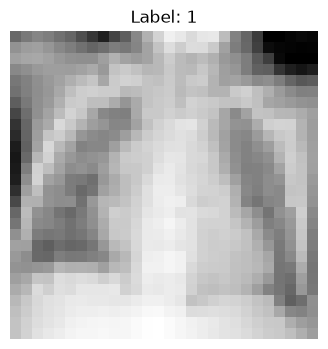

In [36]:
plt.figure(figsize=(4, 4))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

## Class Distribution Analysis

Before model training, the class distribution is examined to identify
potential imbalance between normal and pneumonia cases. Class imbalance
is particularly important in medical classification because accuracy
alone may conceal poor performance on clinically important classes.

In [37]:
from collections import Counter

train_labels = [
    int(train_dataset[i][1].item())
    for i in range(len(train_dataset))
]

class_counts = Counter(train_labels)

label_names = {
    0: "Normal",
    1: "Pneumonia"
}

for class_id, count in sorted(class_counts.items()):
    percentage = 100 * count / len(train_dataset)
    print(
        f"{label_names[class_id]}: "
        f"{count} images ({percentage:.2f}%)"
    )

Normal: 1214 images (25.79%)
Pneumonia: 3494 images (74.21%)


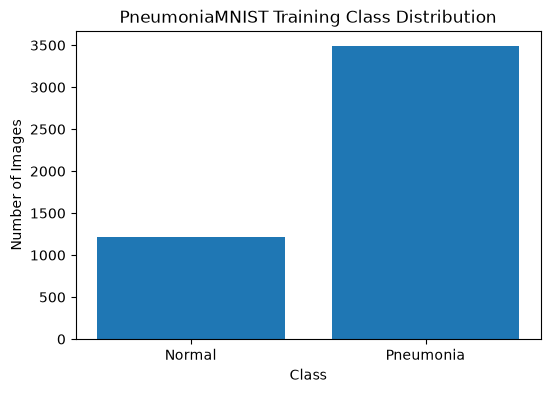

In [38]:
classes = [label_names[i] for i in sorted(class_counts)]
counts = [class_counts[i] for i in sorted(class_counts)]

plt.figure(figsize=(6, 4))
plt.bar(classes, counts)
plt.title("PneumoniaMNIST Training Class Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()

### Observation

The PneumoniaMNIST training set exhibits substantial class imbalance.
Of the 4,708 training images, 3,494 (74.21%) represent pneumonia cases,
whereas 1,214 (25.79%) represent normal cases.

This imbalance is important when interpreting model performance. A
classifier that predicts the majority pneumonia class for every training
sample would achieve approximately 74.21% accuracy without learning a
clinically useful decision boundary.

Consequently, accuracy alone will not be considered sufficient for
evaluating the baseline model. Evaluation will additionally consider
class-specific performance and metrics including sensitivity, specificity,
precision, F1-score, AUROC, and the confusion matrix.

For this initial baseline experiment, the original class distribution will
be retained rather than corrected through resampling. This provides a
reference model whose behaviour under the benchmark distribution can be
examined before introducing additional interventions in subsequent
experiments.

In [41]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Batch size: 64
Training batches: 74
Validation batches: 9
Test batches: 10


In [42]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10].squeeze().tolist())

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64, 1])
First 10 labels: [1, 0, 1, 0, 0, 1, 0, 1, 1, 1]


## Baseline CNN Architecture

A simple convolutional neural network is used as the baseline model.

The architecture is intentionally lightweight because the goal of
Experiment 001 is not to maximise benchmark performance, but to establish
a clear, reproducible reference model for later experiments on calibration,
uncertainty, robustness, and distribution shift.

In [43]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [44]:
model = BaselineCNN().to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [45]:
nn.BCEWithLogitsLoss()

BCEWithLogitsLoss()

## Loss Function and Optimizer

Binary cross-entropy with logits is used because PneumoniaMNIST is a
binary classification task.

The model outputs raw logits during training. Probabilities are produced
with the sigmoid function only when predictions need to be interpreted
or evaluated.

In [46]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [47]:
sample_images, sample_labels = next(iter(train_loader))

sample_images = sample_images.to(device)

with torch.no_grad():
    sample_logits = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output logits shape:", sample_logits.shape)
print("First 5 logits:", sample_logits[:5].squeeze().cpu().numpy())

Input shape: torch.Size([64, 1, 28, 28])
Output logits shape: torch.Size([64, 1])
First 5 logits: [-0.09475981 -0.09221969 -0.07945276 -0.09258684 -0.07337853]


## Training and Validation

The baseline CNN is trained using the training split and evaluated on the
validation split after each epoch. Training and validation loss are recorded
to examine whether the model is learning effectively and whether signs of
overfitting emerge.


In [48]:
EPOCHS = 10

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # -------------------
    # Training
    # -------------------
    model.train()

    running_train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # -------------------
    # Validation
    # -------------------
    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {avg_train_loss:.4f} "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/10] Train Loss: 0.3391 Val Loss: 0.1719
Epoch [2/10] Train Loss: 0.1650 Val Loss: 0.1387
Epoch [3/10] Train Loss: 0.1389 Val Loss: 0.1094
Epoch [4/10] Train Loss: 0.1203 Val Loss: 0.1090
Epoch [5/10] Train Loss: 0.1101 Val Loss: 0.1228
Epoch [6/10] Train Loss: 0.0954 Val Loss: 0.1150
Epoch [7/10] Train Loss: 0.0945 Val Loss: 0.0891
Epoch [8/10] Train Loss: 0.0855 Val Loss: 0.0935
Epoch [9/10] Train Loss: 0.0809 Val Loss: 0.0913
Epoch [10/10] Train Loss: 0.0758 Val Loss: 0.0944


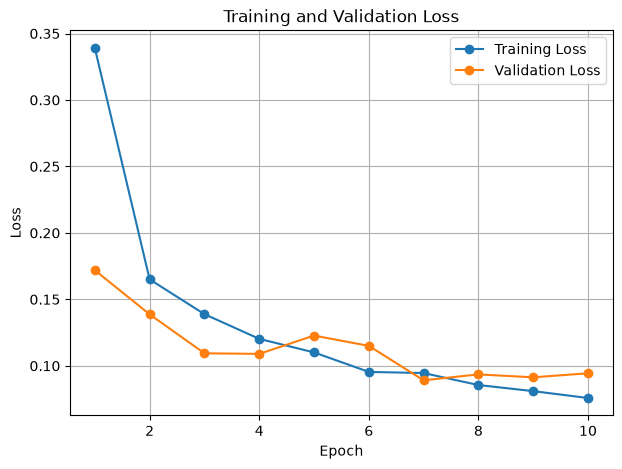

In [49]:
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

## Held-Out Test Evaluation

Following training and validation, the final baseline model is evaluated
on the held-out PneumoniaMNIST test set.

The test data were not used for model training or validation. This
provides an independent assessment of the model's predictive performance
on unseen samples.

Because the dataset is class imbalanced, accuracy alone is insufficient.
Predictions and probabilities are therefore collected for subsequent
evaluation using class-specific and discrimination metrics.

In [50]:
model.eval()

all_labels = []
all_probabilities = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        logits = model(images)

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        all_labels.extend(
            labels.cpu().numpy().flatten()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy().flatten()
        )

        all_predictions.extend(
            predictions.cpu().numpy().flatten()
        )

all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)
all_predictions = np.array(all_predictions)

print("Test samples evaluated:", len(all_labels))
print("First 10 true labels:", all_labels[:10])
print("First 10 probabilities:", all_probabilities[:10])
print("First 10 predictions:", all_predictions[:10])

Test samples evaluated: 624
First 10 true labels: [1. 0. 1. 0. 1. 1. 1. 1. 1. 0.]
First 10 probabilities: [0.9999862  0.99980015 0.94250643 0.00301328 0.99997175 0.9999695
 0.9996326  0.99997425 0.99925905 0.99452823]
First 10 predictions: [1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]


In [51]:
torch.sigmoid(logits)

tensor([[0.9855],
        [0.9289],
        [0.2332],
        [0.9961],
        [0.9987],
        [0.9999],
        [0.9981],
        [1.0000],
        [0.0216],
        [0.9999],
        [1.0000],
        [0.9848],
        [0.0574],
        [0.8249],
        [0.9998],
        [1.0000],
        [0.9981],
        [0.1798],
        [1.0000],
        [0.0623],
        [0.9991],
        [0.9996],
        [0.6748],
        [0.9454],
        [0.9998],
        [0.9965],
        [0.0067],
        [1.0000],
        [0.9909],
        [0.9742],
        [0.2232],
        [1.0000],
        [0.4489],
        [0.9683],
        [0.9998],
        [0.9128],
        [1.0000],
        [0.9974],
        [0.0216],
        [0.9975],
        [1.0000],
        [0.9993],
        [0.7634],
        [0.0578],
        [0.6718],
        [0.0954],
        [0.9438],
        [0.1251]])

### Classification Performance

Performance is evaluated using multiple metrics to account for the
imbalanced class distribution. In addition to accuracy, sensitivity,
specificity, precision, F1-score, and AUROC are reported.

Sensitivity measures the model's ability to identify pneumonia cases,
whereas specificity measures its ability to correctly identify normal
cases. AUROC evaluates discrimination across classification thresholds
rather than relying solely on the default probability threshold of 0.5.

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

sensitivity = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

auroc = roc_auc_score(
    all_labels,
    all_probabilities
)

tn, fp, fn, tp = confusion_matrix(
    all_labels,
    all_predictions
).ravel()

specificity = tn / (tn + fp)

print(f"Accuracy:    {accuracy:.4f}")
print(f"AUROC:       {auroc:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"F1-score:    {f1:.4f}")

print("\nConfusion Matrix Counts")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

Accuracy:    0.8846
AUROC:       0.9370
Sensitivity: 0.9846
Specificity: 0.7179
Precision:   0.8533
F1-score:    0.9143

Confusion Matrix Counts
True Negatives:  168
False Positives: 66
False Negatives: 6
True Positives:  384


### Confusion Matrix

The confusion matrix provides a class-specific view of prediction errors.
This is particularly important for medical classification because false
negative and false positive predictions may have different practical
consequences.

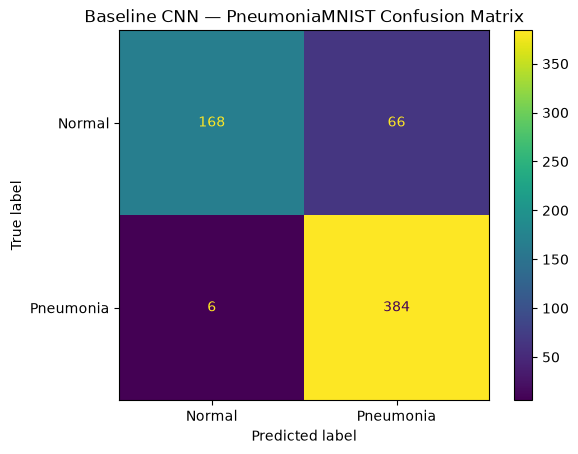

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pneumonia"]
)

disp.plot()

plt.title("Baseline CNN — PneumoniaMNIST Confusion Matrix")
plt.show()

## Experiment 001 — Conclusion

The baseline CNN achieved 88.46% accuracy and an AUROC of 0.9370 on the
held-out PneumoniaMNIST test set, demonstrating strong overall
discriminative performance.

The model achieved very high sensitivity (98.46%), correctly identifying
384 of 390 pneumonia cases and producing only six false negatives.
However, specificity was considerably lower at 71.79%, with 66 normal
cases incorrectly classified as pneumonia.

These results demonstrate that aggregate accuracy alone does not fully
characterise model behaviour in an imbalanced medical classification
setting. The substantial difference between sensitivity and specificity
highlights the importance of class-specific evaluation.

Furthermore, inspection of predicted probabilities shows that some
incorrect predictions can be associated with very high model confidence.
Therefore, strong classification performance does not necessarily imply
that predicted probabilities are reliable.

This baseline establishes the reference point for subsequent experiments
investigating probability calibration, uncertainty quantification, and
robustness under distribution shift.

In [54]:
import pandas as pd
from pathlib import Path

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUROC",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1-score"
    ],
    "Value": [
        accuracy,
        auroc,
        sensitivity,
        specificity,
        precision,
        f1
    ]
})

results.to_csv(
    results_dir / "experiment_001_baseline_metrics.csv",
    index=False
)

results

,Metric,Value
0,Accuracy,0.884615
1,AUROC,0.936993
2,Sensitivity,0.984615
3,Specificity,0.717949
4,Precision,0.853333
5,F1-score,0.914286
